# MicroEconoPycs
A tool to analyze domestic finances

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from src import config
from src.movements import Movements, Operations, Timeseries, SpendingPatterns
from src.graphics import Plots

## Setup
Note that the `cfg` dataclass has in it all the information needed to retrieve the correct source data spreadsheet. If the used wants to use a different file, it can be passed as argument to the `src.movements` classes.

In [3]:
# Instantiate configuration
plots_backend = "matplotlib"
cfg = config.Constants("./config/config.json")

## Operations: Aggregated Expenses Volume
### Foundation

The task is to analyze past data to describe the volumes of the expense items. This gives a visual insight about what are the elements that weigh more on the overall capital balance.

This can be done with both
* Incomes: The percentages of the income volumes
* Outputs: The percentages of expense items

The `Operations` class provides a method `print_expected_delta`, that prints the estimated end-of-month delta. This is the approximation of action of the operator $\Phi$ on the capital state $\mathbf{x}$ at time $t$, assuming the following underlying dynamics

$\mathbf{x}_{t+1} = \mathbf{x}_t + \Phi(\mathbf{x}_t)$

The temporal resolution is monthly. So $t$ is the end of a month, $t+1$ is the end of the next month. The evaluation of the incremental expression is obtained by summing the overall inputs and the overall expenses

$\Phi(\mathbf{x}_t) = \displaystyle \int_{t}^{t + 1} \,  \left\{ \sum_{i \in \mathcal{C}_i} \mathrm{Input}_i(t) - \sum_{e \in \mathcal{C}_e} \mathrm{Output}_e(t) \right\} \,\mathrm{d}t $

Where $\mathcal{C}_i$ and $\mathcal{C}_e$ are the income and expense items respectively. These are encoded by the `Category` column in the source file. Roughly, the increment is the net different between all that entered and all that quitted.

**NOTE**: The operator $\Phi$ encodes the net monthly delta **referred to the analyzed year**.

In [4]:
# Instantiate and set up operations class
operations = Operations(cfg)
operations.setup()

# Print the expected monthly delta
operations.print_expected_delta()

Expected Delta = 372.58 EUR / Month


### Visualization

#### Incomes plot
(The first graphic) disaggregates the inputs. This is the positive part of $\Phi$.

#### Expense items plot
(The second graphics) disaggregated the expense items. This is a disaggregated negative part of $\Phi$

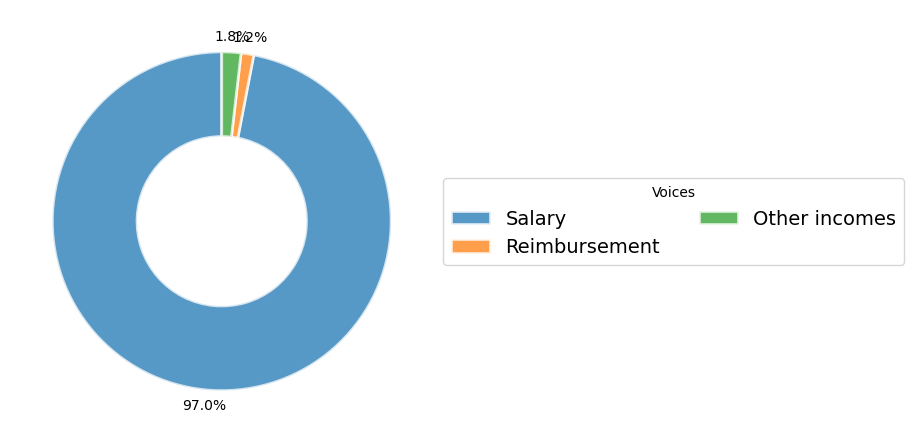

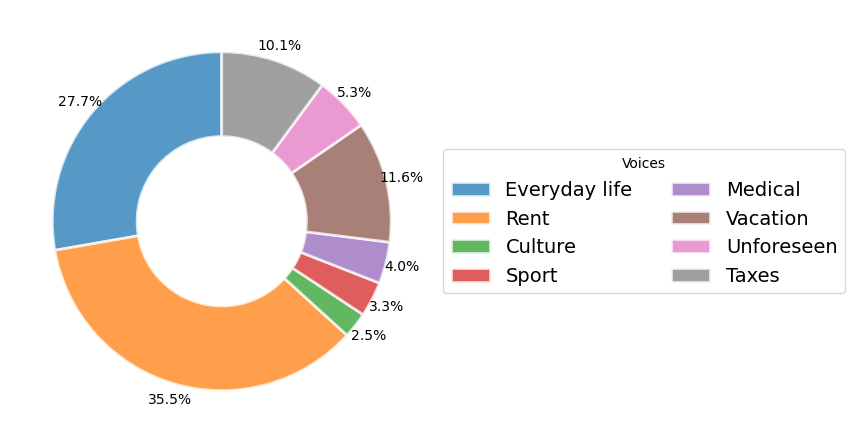

In [5]:
# Plot the income/expense voices
fig_incomes, fig_expenses = Plots.plot_expense_items(operations, backend = plots_backend)

if plots_backend == "plotly":
    fig_incomes.show()
    fig_expenses.show()

## Timeseries: Deduction of the linear growth trend
### Foundation

The structure of the source spreadsheet is a collection of rows, with
* Date
* Category
* Amount

It may be that in the same day one has multiple expense items of different categories and no other expenses for the following $n$ days. There is no a fixed day-by-day structure. The `Timeseries` class gathers the methods to recombine the data so to obey a clear chronological pattern. The end result of the `setup` method is a `pandas.DataFrame` structure with 
* Date
* Category
* Input (Istantaneous)
* Output (Istantaneous)
* Cumulative input
* Cumulative output

This structure has exactly as many rows as the days of the year. Each row aggregates the input and output items according to the input/expense category belongingess. The cumulative fluxes are used to compute the net availability for each day, according to the expression

$\mathrm{Available}(t) = \displaystyle \sum_{k = 0}^{t} \left\{ \mathrm{Available}(k) + \mathrm{Input}(k) - \mathrm{Output}(k) \right\} $

In this case, $t$, $k$ are **day indices**. Note that the monthly aggregation of this expression reduces to the evaluation of the operator $\Phi$ stated in the previous section. Here, the category belongingness is neglected in favor of anonimized istantaneous input/output fluxes.

This data representation allows to track the trend of overall input and overall output. More important, these curves allow us to estimate the **net daily gain**. That is, how much one can save of the overall input fluxes given the aggregated lifestyle cost. This estimation is done simply by dividing the estimated end-of-month delta. The method `fit_trendline_coefficients` gives exactly this quantity. The resulting trendline can be used to estimate the capital growth ahead in time.

The method `sumup_printout` prints a summary table, with
* The initial stock, at January 1st of the analyzed year
* The final stock, at December 31st
* The average stock, that is the average over the year of the instantaneous availability
* The net daily gain

In [6]:
# Instantiate and set up timeseries class
timeseries = Timeseries(cfg)
timeseries.setup()

# Fit the trendline coefficients
timeseries.fit_trendline_coefficients()

# Print yearly statistics
timeseries.sumup_printout()


       Summary statistic year 2024 Amount (EUR)
0   Initial stock (at 2024-01-01)      5000.15
1     Final stock (at 2024-12-31)      9471.15
2                   Average stock      7875.42
3  Estimated daily capital growth        12.22


### Visualization
It is possible to plot the result of the `setup` method. That is, the fixed daily trend of the istantaneous and cumulative input/output fluxes and the availability.

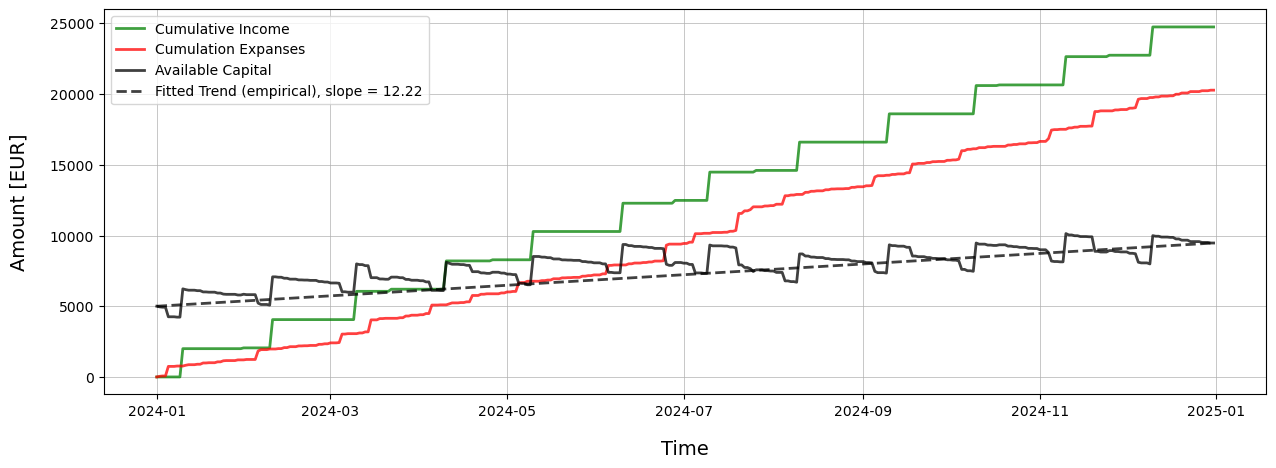

In [7]:
# Plot the timeseries reconstruction
fig_timeseries = Plots.plot_trend(timeseries, backend = plots_backend)

if plots_backend == "plotly":
    fig_timeseries.show()

## Future Simulations
### Foundation

The interesting aspect of the framework is the possibility to run simulations of possible future scenarios. These scenarios are simulated based on the spending habits of the year analyzed.

The class `SpendingPatterns` takes the source spreadsheet and, based on the input/output statistics (amounts, inter-arrival times) estimates likely spending patterns. These patterns are used to perform $k$-years ahead probabilistic predictions. The method `fit` produces a source data spreadsheet in the same format as the data expected as input for the other `movements` classes. Formally, it is a collection

$\left\{ (\mathrm{Input}_i(t), \mathrm{Output}_e(t)); \, t \in [t_0, t_T] \right\}$

Where $t_0$, $t_T$ are the initial time (Jan 1st of the analyzed year) and the last day of the time horizon selected (December 31st of the last year, according to the configured setting). The inputs and outputs are sampled by the empirical distributions of inputs and outputs of the analyzed year. That is

$\mathrm{Input}_i(t_i) \sim P_i ; \; t_i \sim P_{t_i} \; \; i \in \mathcal{C}_i$

Recall that $\mathcal{C}_i$ is the set of all the income categories. The same extends identically to expenses. $P_i$ is the empirical distribution of expenses of the category $i$. The inter-arrival time $t_i$ (and note that timestamps are not necessarily evenly spaced in the raw data) is a random variable as well. It is sampled from the empirical distribution of the inter-arrival times for category $i$. It can be represented as 

$t_i(k) = t_i(k-1) + \Delta t_i$

The indices $k$ are incremental indices, but the timestamps $t_i(k)$ and $t_i(k-1)$ may be spaced of several days. Example: If the category $i$ is a everyday life expense, it is likely that the inter-arrival time of such an expense may be 1 to 5 days. If $i$ is the category of medical expenses, the inter-arrival time of such an expense is, hopefully, up to months.

The framework allow to run multiple runs simulations, in order to estimate the average trend.
____

### Configuration

The `config.json` file allows one to encode deterministically the predictable input/output rules. For example, rent is deterministic, as it is due each month. 

The rules are encoded in the configuration file as follows:
* Specify `Day`, `Month` and `Year` for *una tantum* outputs. E.g. It is certain that at some given day, there will be such expense
* Specify `Day` and `Month` for yearly recurrent expenses ‒ that are predicted and scheduled once a year
* Specify `Day` for monthly recurrent expenses. E.g. Rent, Salary.

Don't forget the minus sign for the amounts of the expenses!

In [ ]:
# Extrapolate the spending patterns of the selected year
spending_patterns = SpendingPatterns(cfg)
spending_patterns.fit()

# Perform and ahead-in-time simulation
simulated_inout = spending_patterns.simulate_yearly_expenses(rules = cfg.SIMULATION_COLUMNS_CONSTANTS)

### Visualization
The plot below visualizes the multiple simulation runs (10) over a 2-years simulation time horizon. The method `plot_simulation_runs` gives the possibility to superpose the trendline obtained for the data of the analyzed year. This helps to have an intuition about the likelihood of the simulation. This trendline acts as "baseline", that is: if the spending patterns do not change, I can expect this. 

Of course, the possibility of tuning user-specific rules in `cfg.SIMULATION_COLUMNS_CONSTANTS` allows one to estiamte the future scenario and compare it with the baseline. That is, if I change this spending habit (e.g. I cut down $x$ by $m$ %), I can expect a gain w.r.t the baseline.

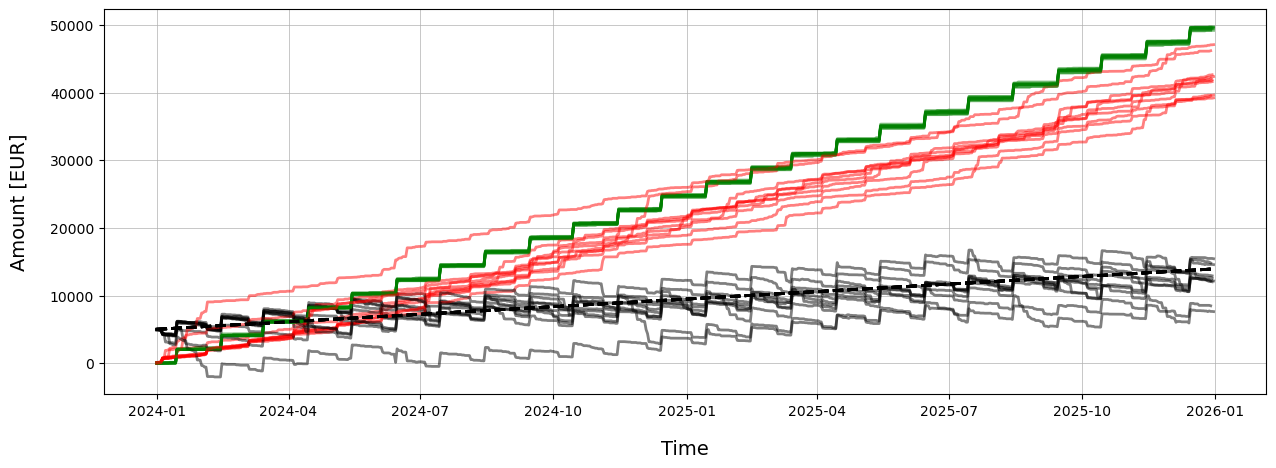

In [9]:
# Instantiate Timeseries classes to host source simulated data
simulated_inout_timeseries = []
for inout in simulated_inout:
    _timeseries = Timeseries(cfg)
    _timeseries.setup(inout)
    simulated_inout_timeseries.append(_timeseries.inout_sheet)

# Plot the simulation runs
fig_simulations = Plots.plot_simulation_runs(
    simulated_inout_timeseries,
    trendline_params = timeseries.estimated_lm_params,
    plot_trend_line = True
)

if plots_backend == "plotly":
    fig_simulations.show()